# [LAB-06] 8. Bar・Count Plot

## #01. 준비작업

### 1. 패키지 가져오기

- numpy 패키지가 함께 사용된다.

In [1]:
from jussam import load_data
from helpers import *
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('penguins')
origin

📚 남극 팔머 군도의 펭귄 3종에 대해 신체 치수와 서식지 정보(출처: https://www.kaggle.com/datasets/larsen0966/penguins)

    field              description
--  -----------------  -------------
 0  species            팽귄 종
 1  island             서식지
 2  bill_length_mm     부리 길이
 3  bill_depth_mm      부리 두께
 4  flipper_length_mm  날개 길이
 5  body_mass_g        몸무게
 6  sex                성별



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100,18.700,181,3750,MALE
1,Adelie,Torgersen,39.500,17.400,186,3800,FEMALE
2,Adelie,Torgersen,40.300,18.000,195,3250,FEMALE
3,Adelie,Torgersen,36.700,19.300,193,3450,FEMALE
4,Adelie,Torgersen,39.300,20.600,190,3650,MALE
...,...,...,...,...,...,...,...
329,Gentoo,Biscoe,47.200,13.700,214,4925,FEMALE
330,Gentoo,Biscoe,46.800,14.300,215,4850,FEMALE
331,Gentoo,Biscoe,50.400,15.700,222,5750,MALE
332,Gentoo,Biscoe,45.200,14.800,212,5200,FEMALE


## #02. BarPlot

### 1. 집단별 세로 평균 그래프

- 팽귄 종에 따른 몸무게 평균
  - 집단별 요약 통계 시각화에서 가장 기본이 되는 형태
  - 범주형 분석에서 가장 표준적으로 사용되는 그래프

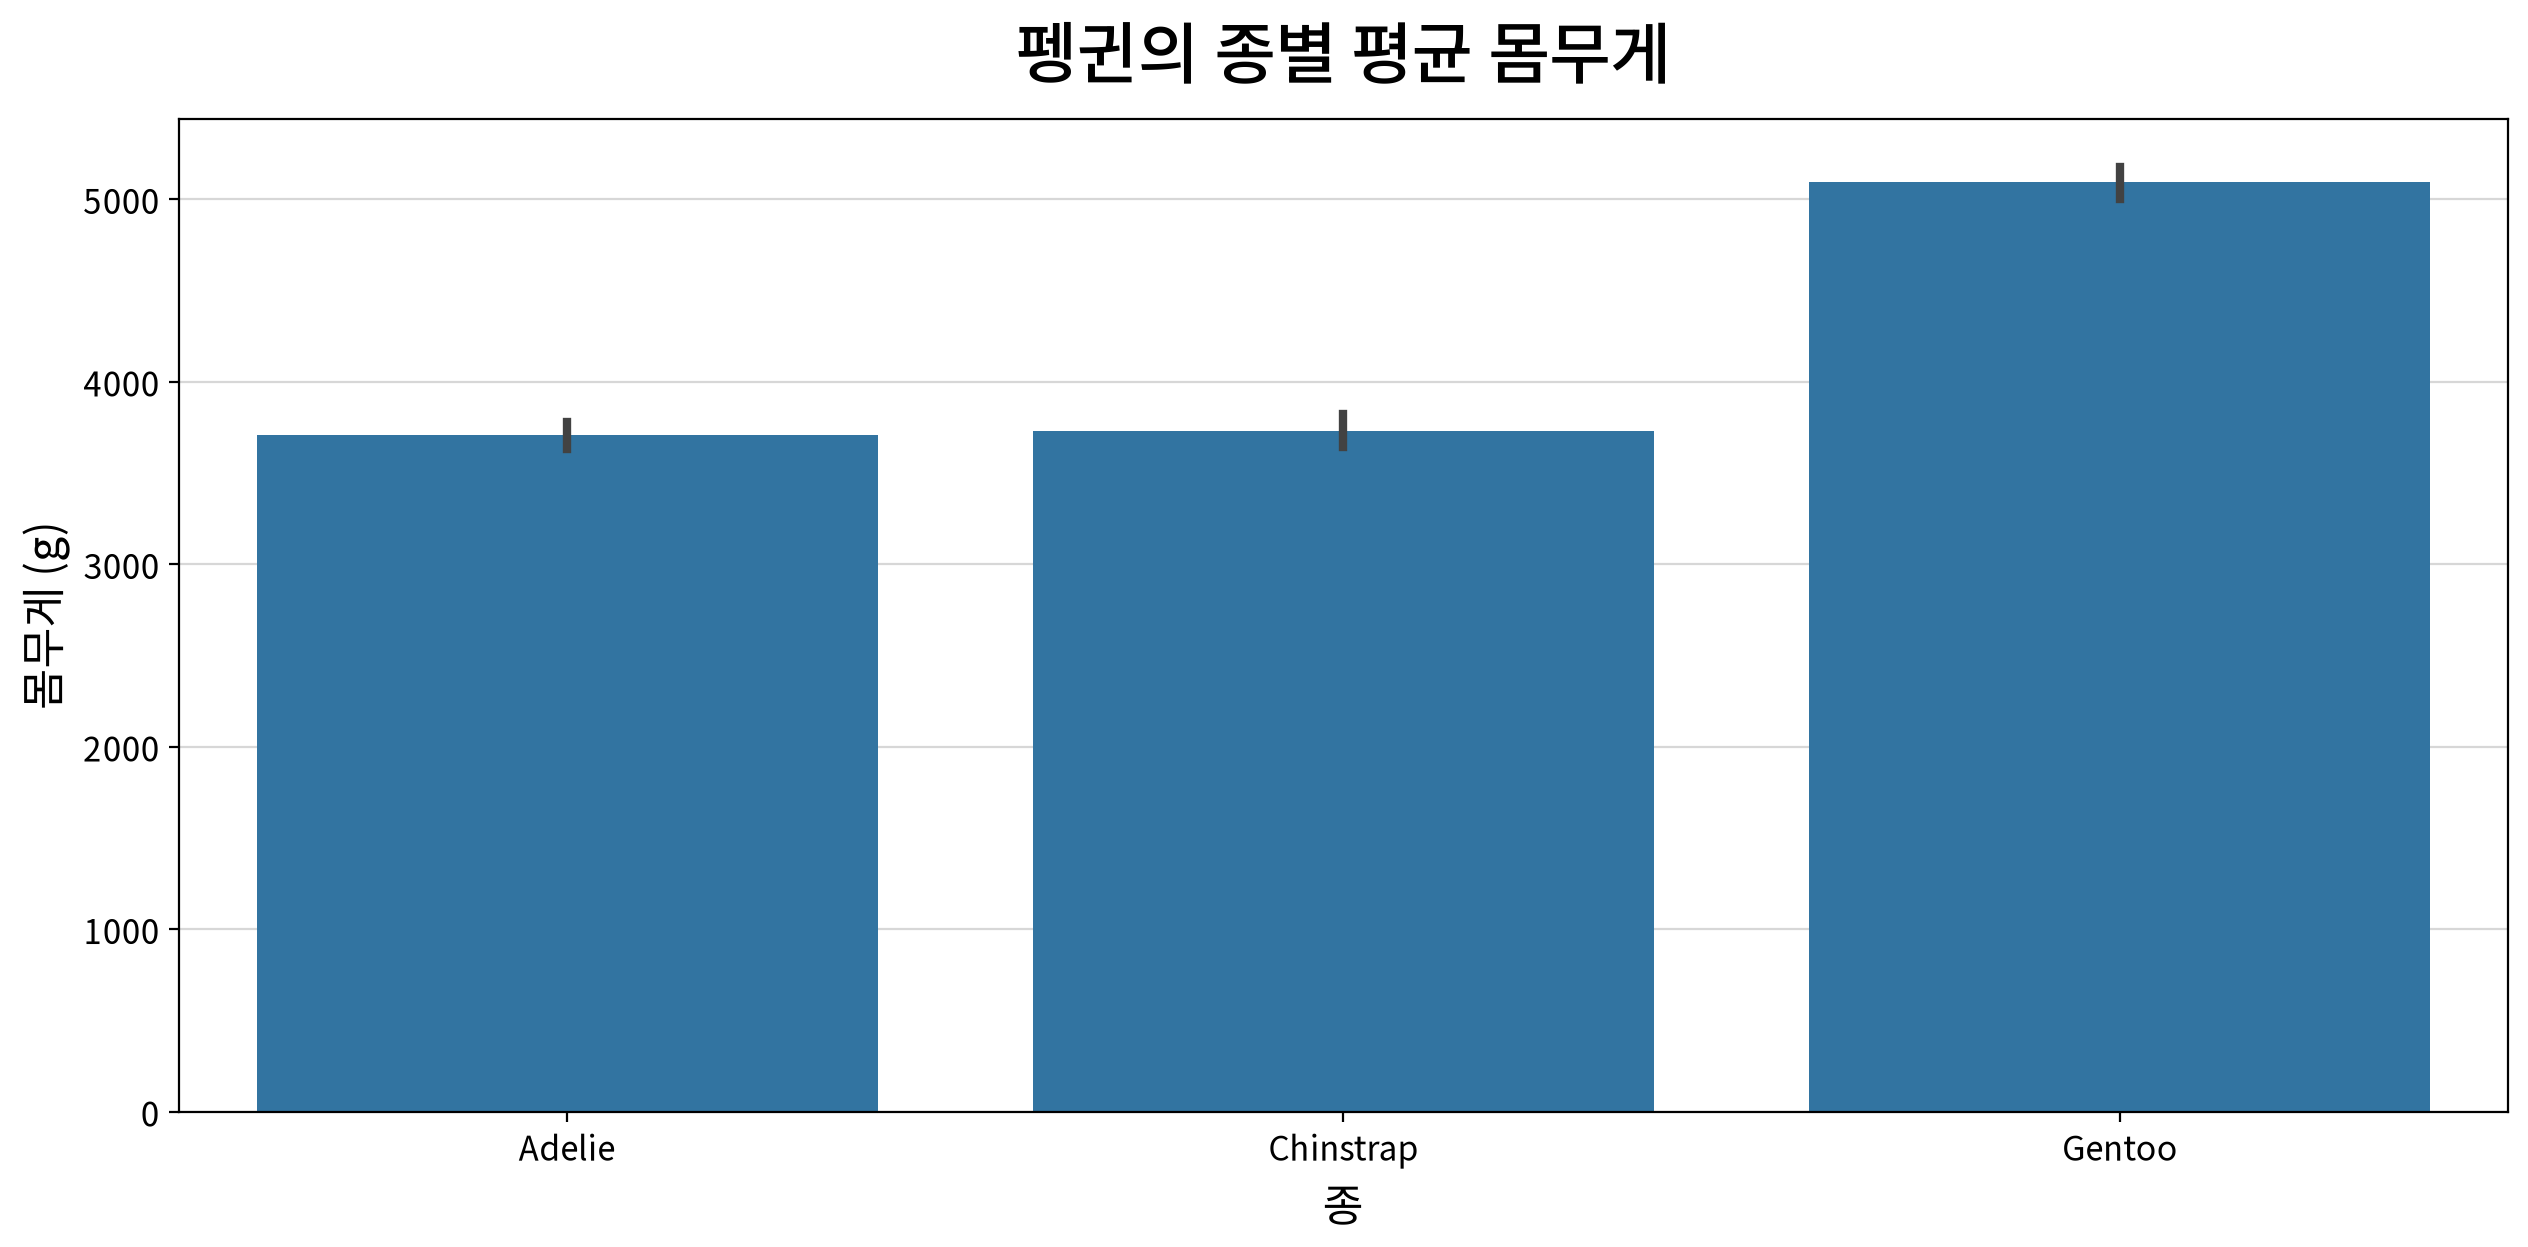

In [3]:
# 그래프 초기화
fig, ax = my_plot.init(title="펭귄의 종별 평균 몸무게", 
                       xlabel="종", ylabel="몸무게 (g)")

# barplot 그리기
sb.barplot(
    data=origin,       # 사용할 데이터프레임
    x="species",       # x축 : 범주형 변수
    y="body_mass_g",   # y축 : 수치형 변수
)

# 그래프 꾸미기
my_plot.show()

#### 💡 인사이트

- 🐧 종별 평균 몸무게는 Gentoo가 가장 높게 나타남(약 5,100g 수준).
- 📊 Adelie와 Chinstrap의 평균 몸무게는 서로 매우 유사함(둘 다 약 3,700g대, Chinstrap이 소폭 높음).
- 📏 Gentoo와 나머지 두 종(Adelie/Chinstrap) 사이 평균 몸무게 차이가 크게 보임(대략 1,300g 내외).
- 🎯 오차막대(error bar) 폭이 전반적으로 크지 않아, 각 종 평균 추정값이 비교적 안정적으로 표현됨.
- 🧭 이 그래프 기준으로는 종(species)에 따라 몸무게 수준이 뚜렷하게 구분되는 패턴이 확인됨.

### 2. 집단별 가로 평균 그래프

- x 파라미터에 수치형 변수, y 파라미터에 범주형 변수를 설정한다.

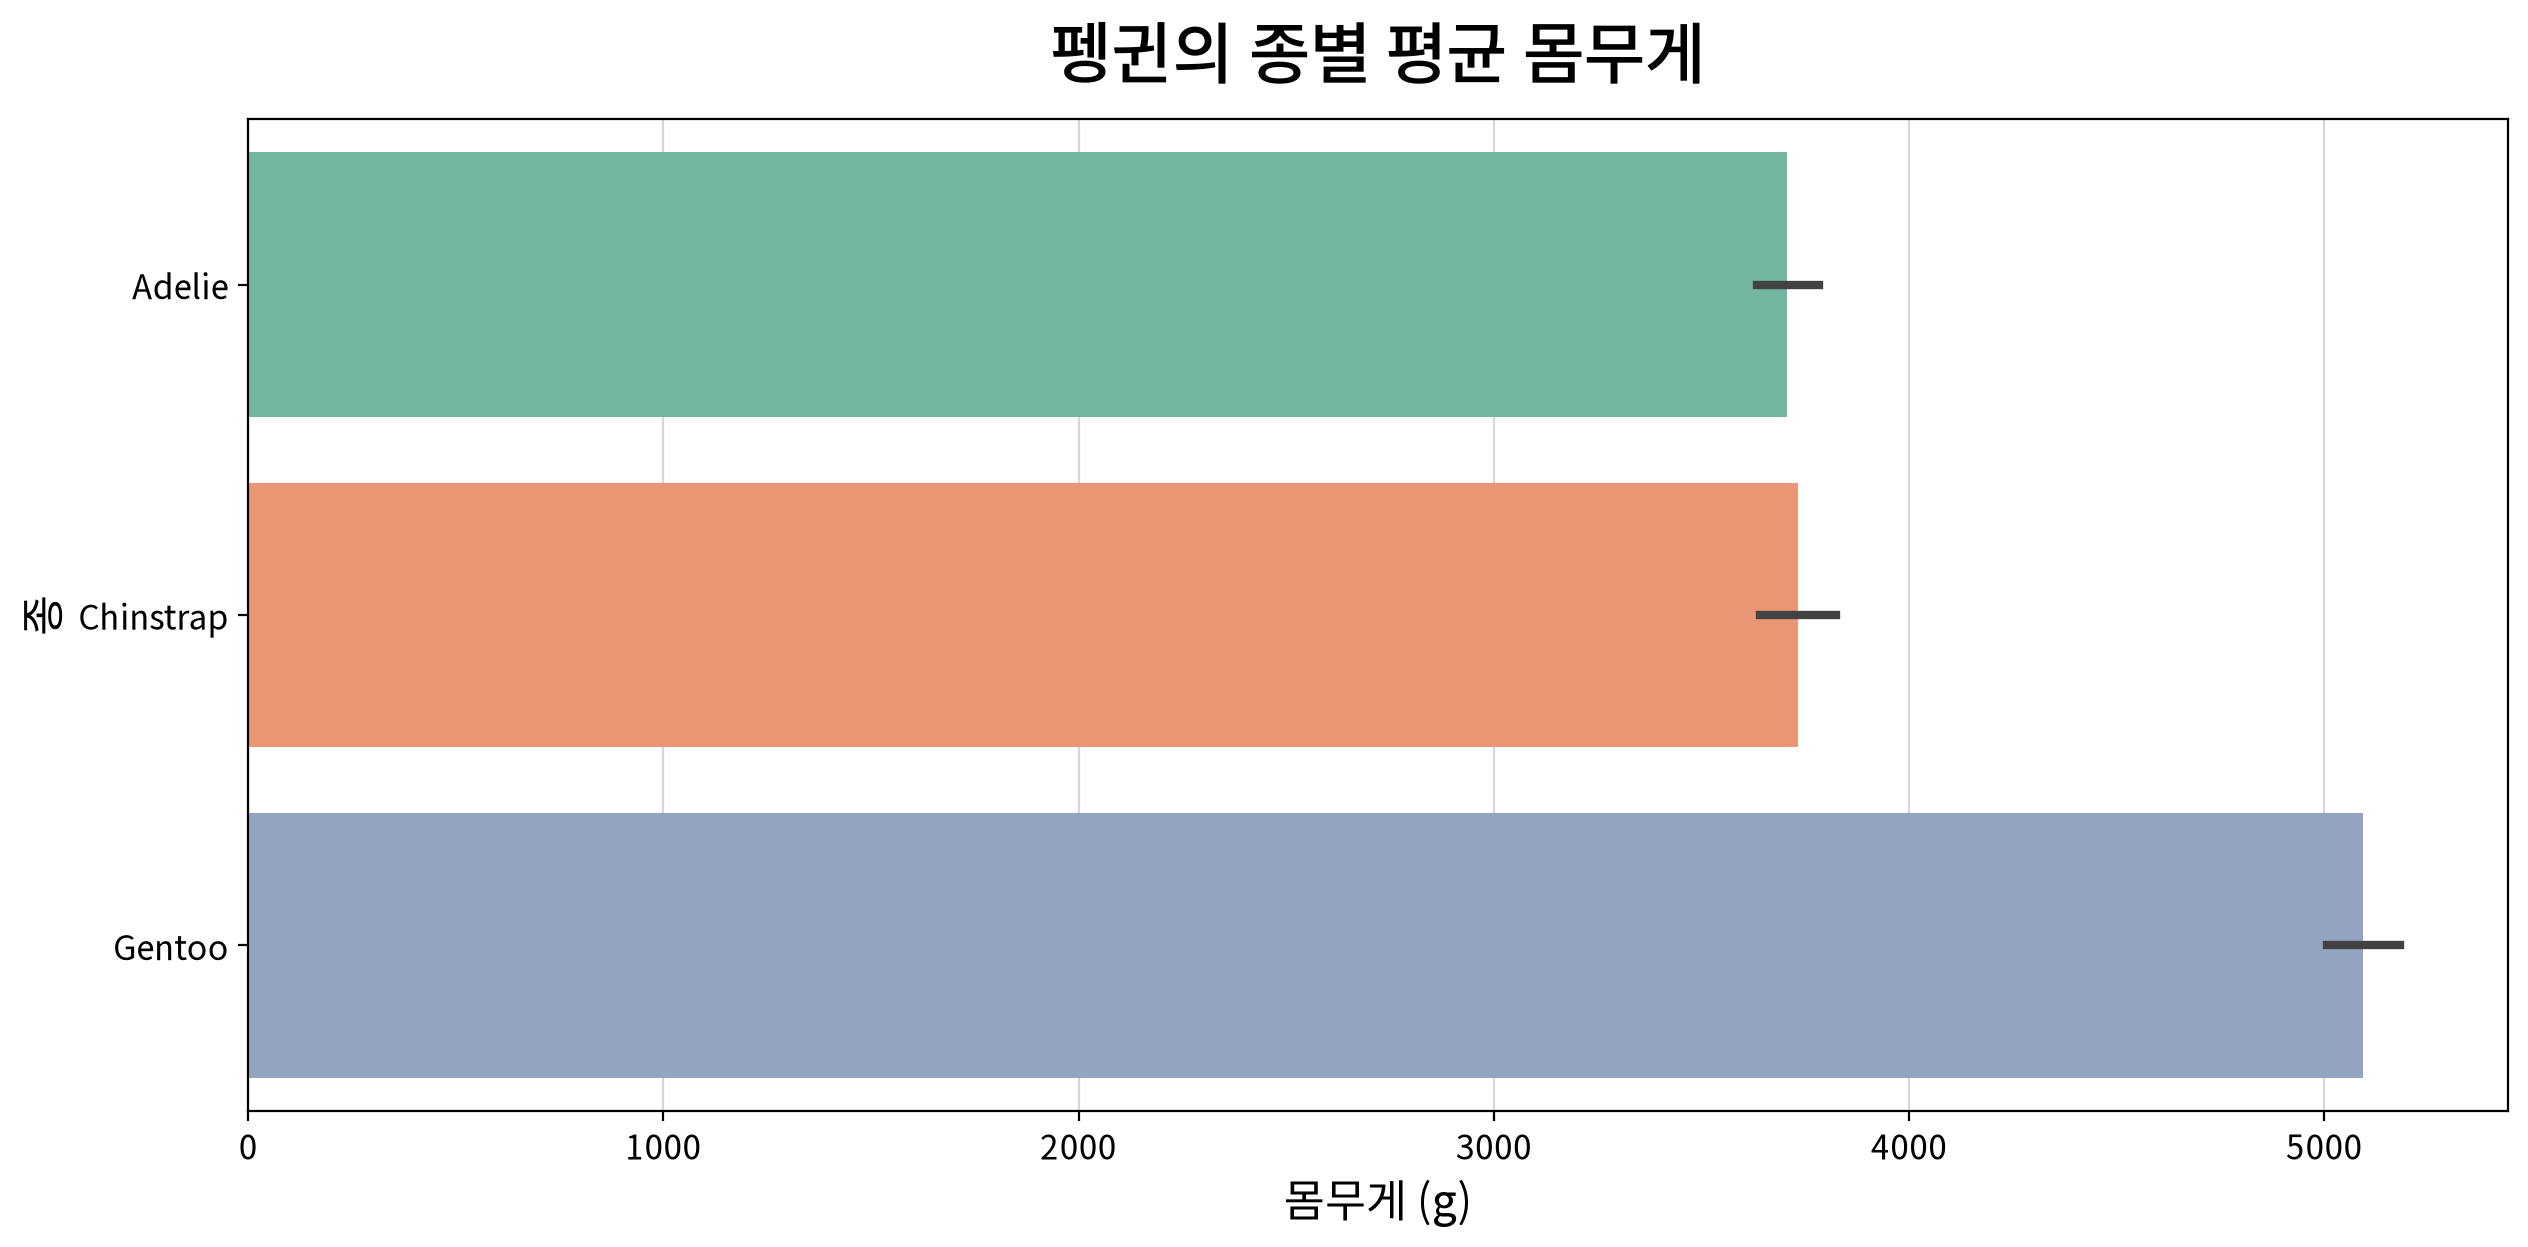

In [4]:
# 그래프 초기화
fig, ax = my_plot.init(title="펭귄의 종별 평균 몸무게", 
                       xlabel="몸무게 (g)", ylabel="종")

# barplot 그리기
sb.barplot(
    data=origin,       # 사용할 데이터프레임
    x="body_mass_g",   # x축 : 수치형 변수
    y="species",       # y축 : 범주형 변수
    palette="Set2",    # 팔레트: "Set2", "pastel", "deep", "bright", ...
    hue="species",     # 팔레트는 반드시 hue와 함께 사용해야 함.
)

# 그래프 표시하기
my_plot.show()

### 3. 다양한 집계 방법 사용하기

- estimator 파라미터에 요약 함수를 지정한다.

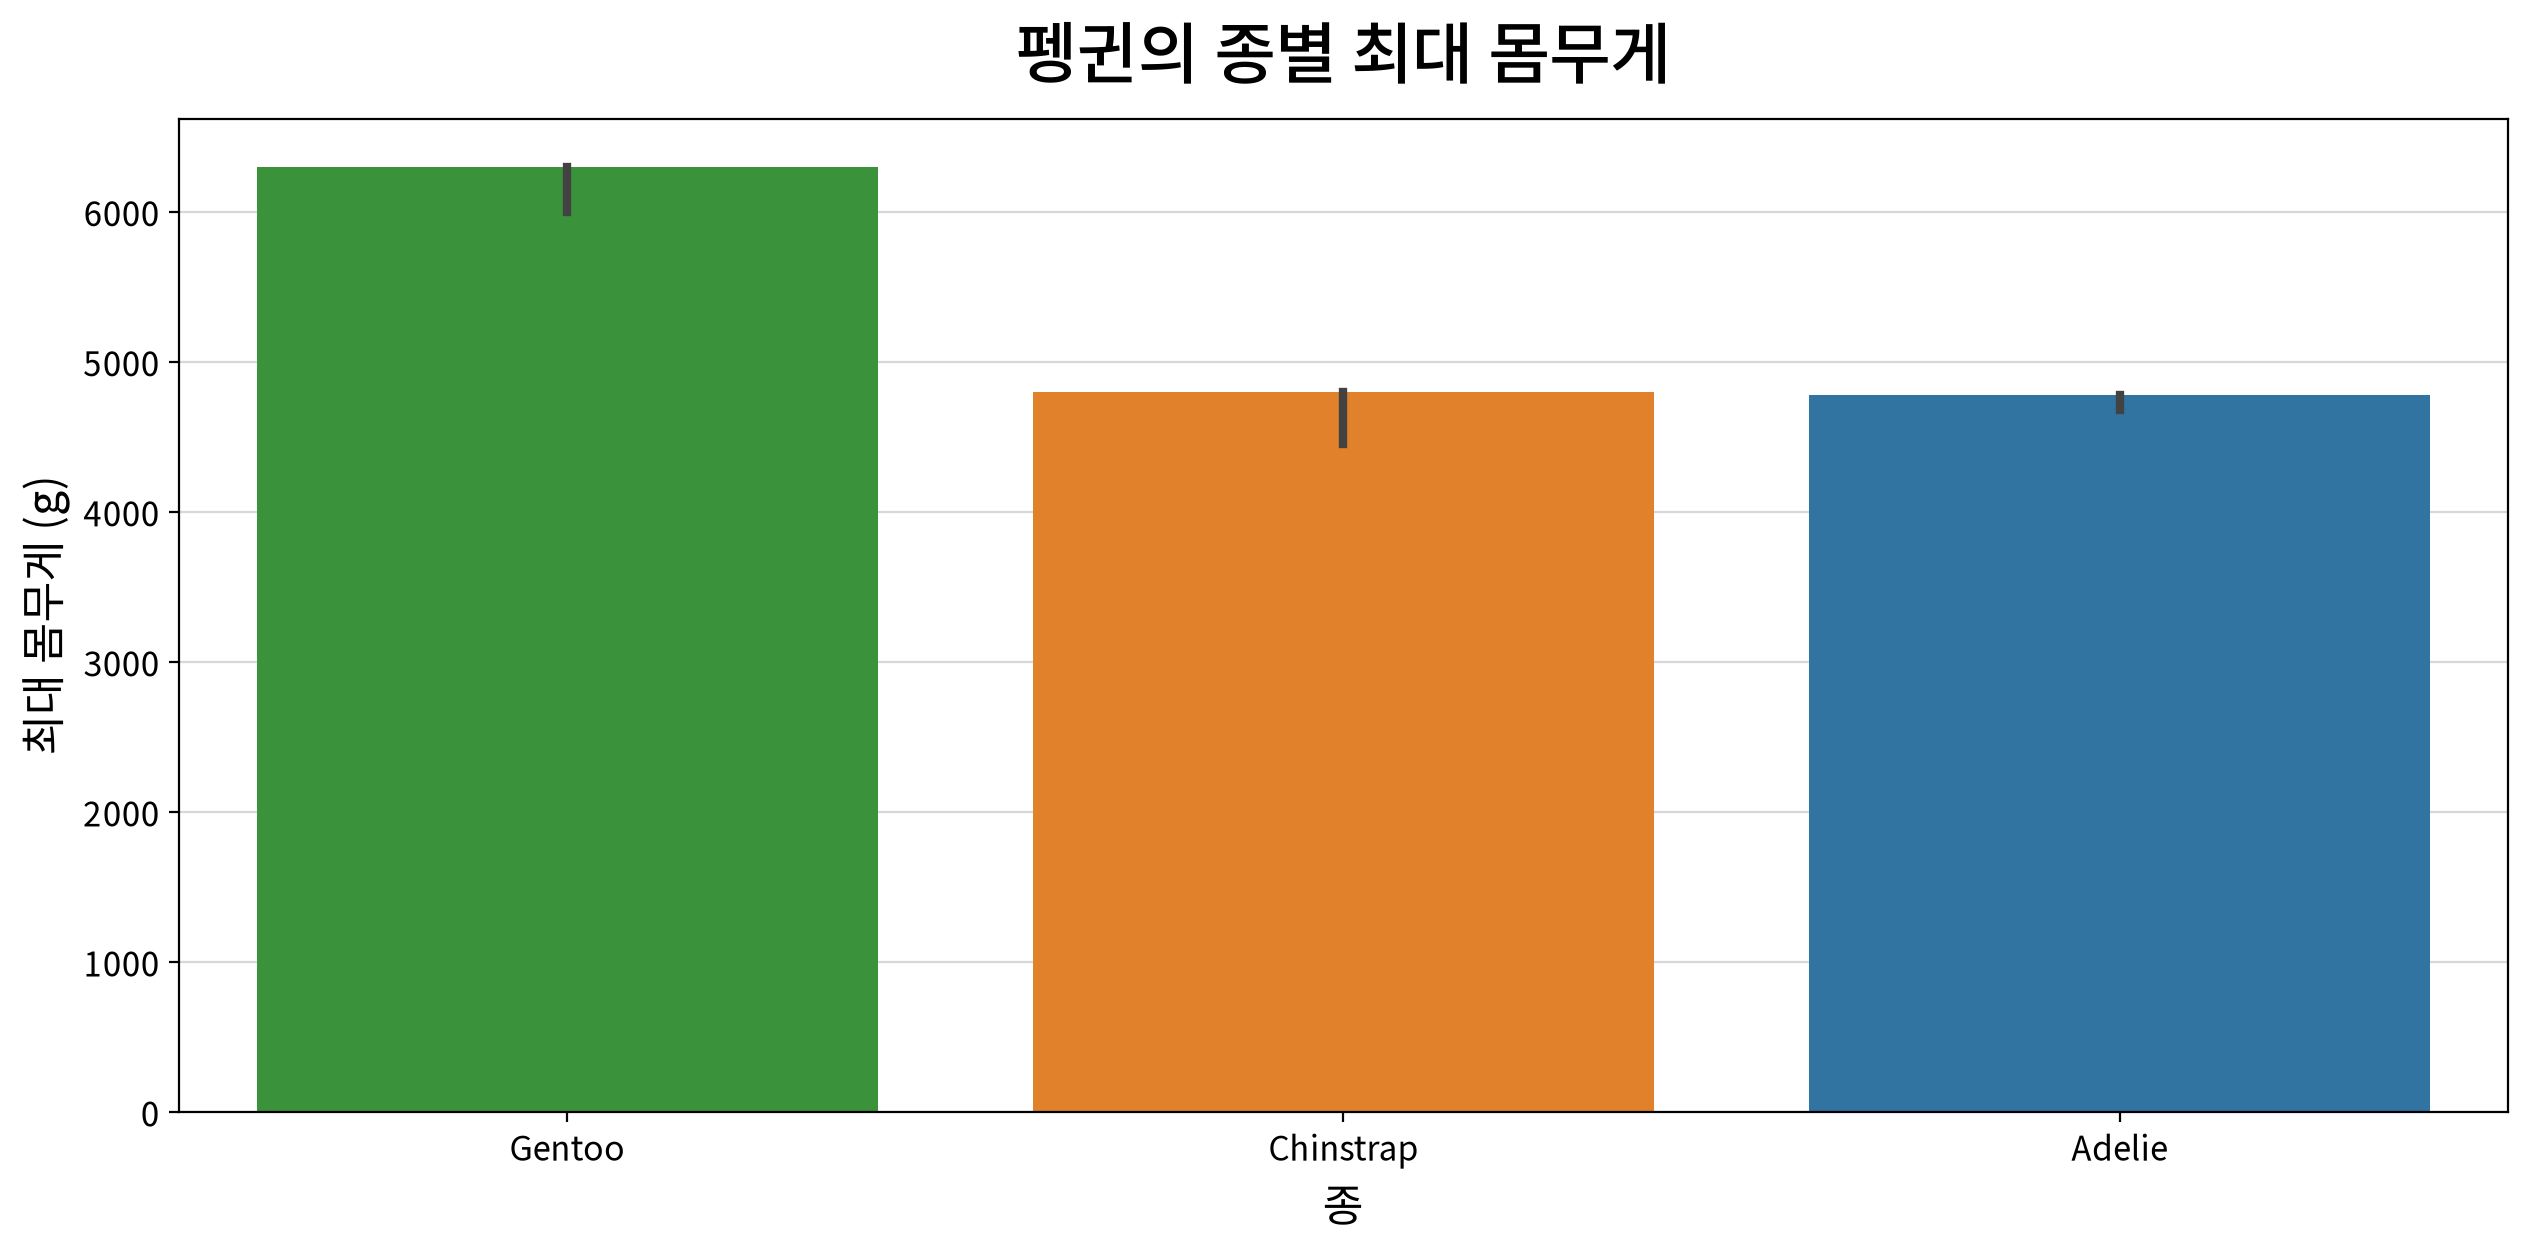

In [5]:
# 그래프 초기화
fig, ax = my_plot.init(title="펭귄의 종별 최대 몸무게", 
                       xlabel="종", ylabel="최대 몸무게 (g)")

# barplot 그리기
sb.barplot(data=origin,  x="species", y="body_mass_g",
           palette="tab10", hue="species",          
           estimator=np.max,                         # 요약 함수
           order=['Gentoo', 'Chinstrap', 'Adelie'],  # 막대의 순서 지정
)

# 그래프 표시하기
my_plot.show()

#### 💡 인사이트

- 🐧 종별 최대 몸무게는 Gentoo가 가장 높게 나타남(약 6,300g 수준).
- 📊 Chinstrap과 Adelie의 최대 몸무게는 서로 매우 비슷한 수준임(둘 다 약 4,800g 내외).
- 📏 Gentoo와 Chinstrap/Adelie 사이 최대 몸무게 차이가 크게 보임(약 1,500g 안팎).
- 🎯 오차막대 기준으로 Chinstrap의 변동 폭이 가장 크게 보이고, Adelie는 가장 작게 보임.
- 🧭 제시된 순서(Gentoo → Chinstrap → Adelie)에서도 최대 몸무게의 우위는 Gentoo가 뚜렷하게 유지됨.

### 4. 범주에 따른 구분

- x축과 hue에 각각 다른 범주형 컬럼을 지정하여 x축에서 구분한 범주에 대하여, hue에 지정한 범주별로 한 번 더 구분한다.

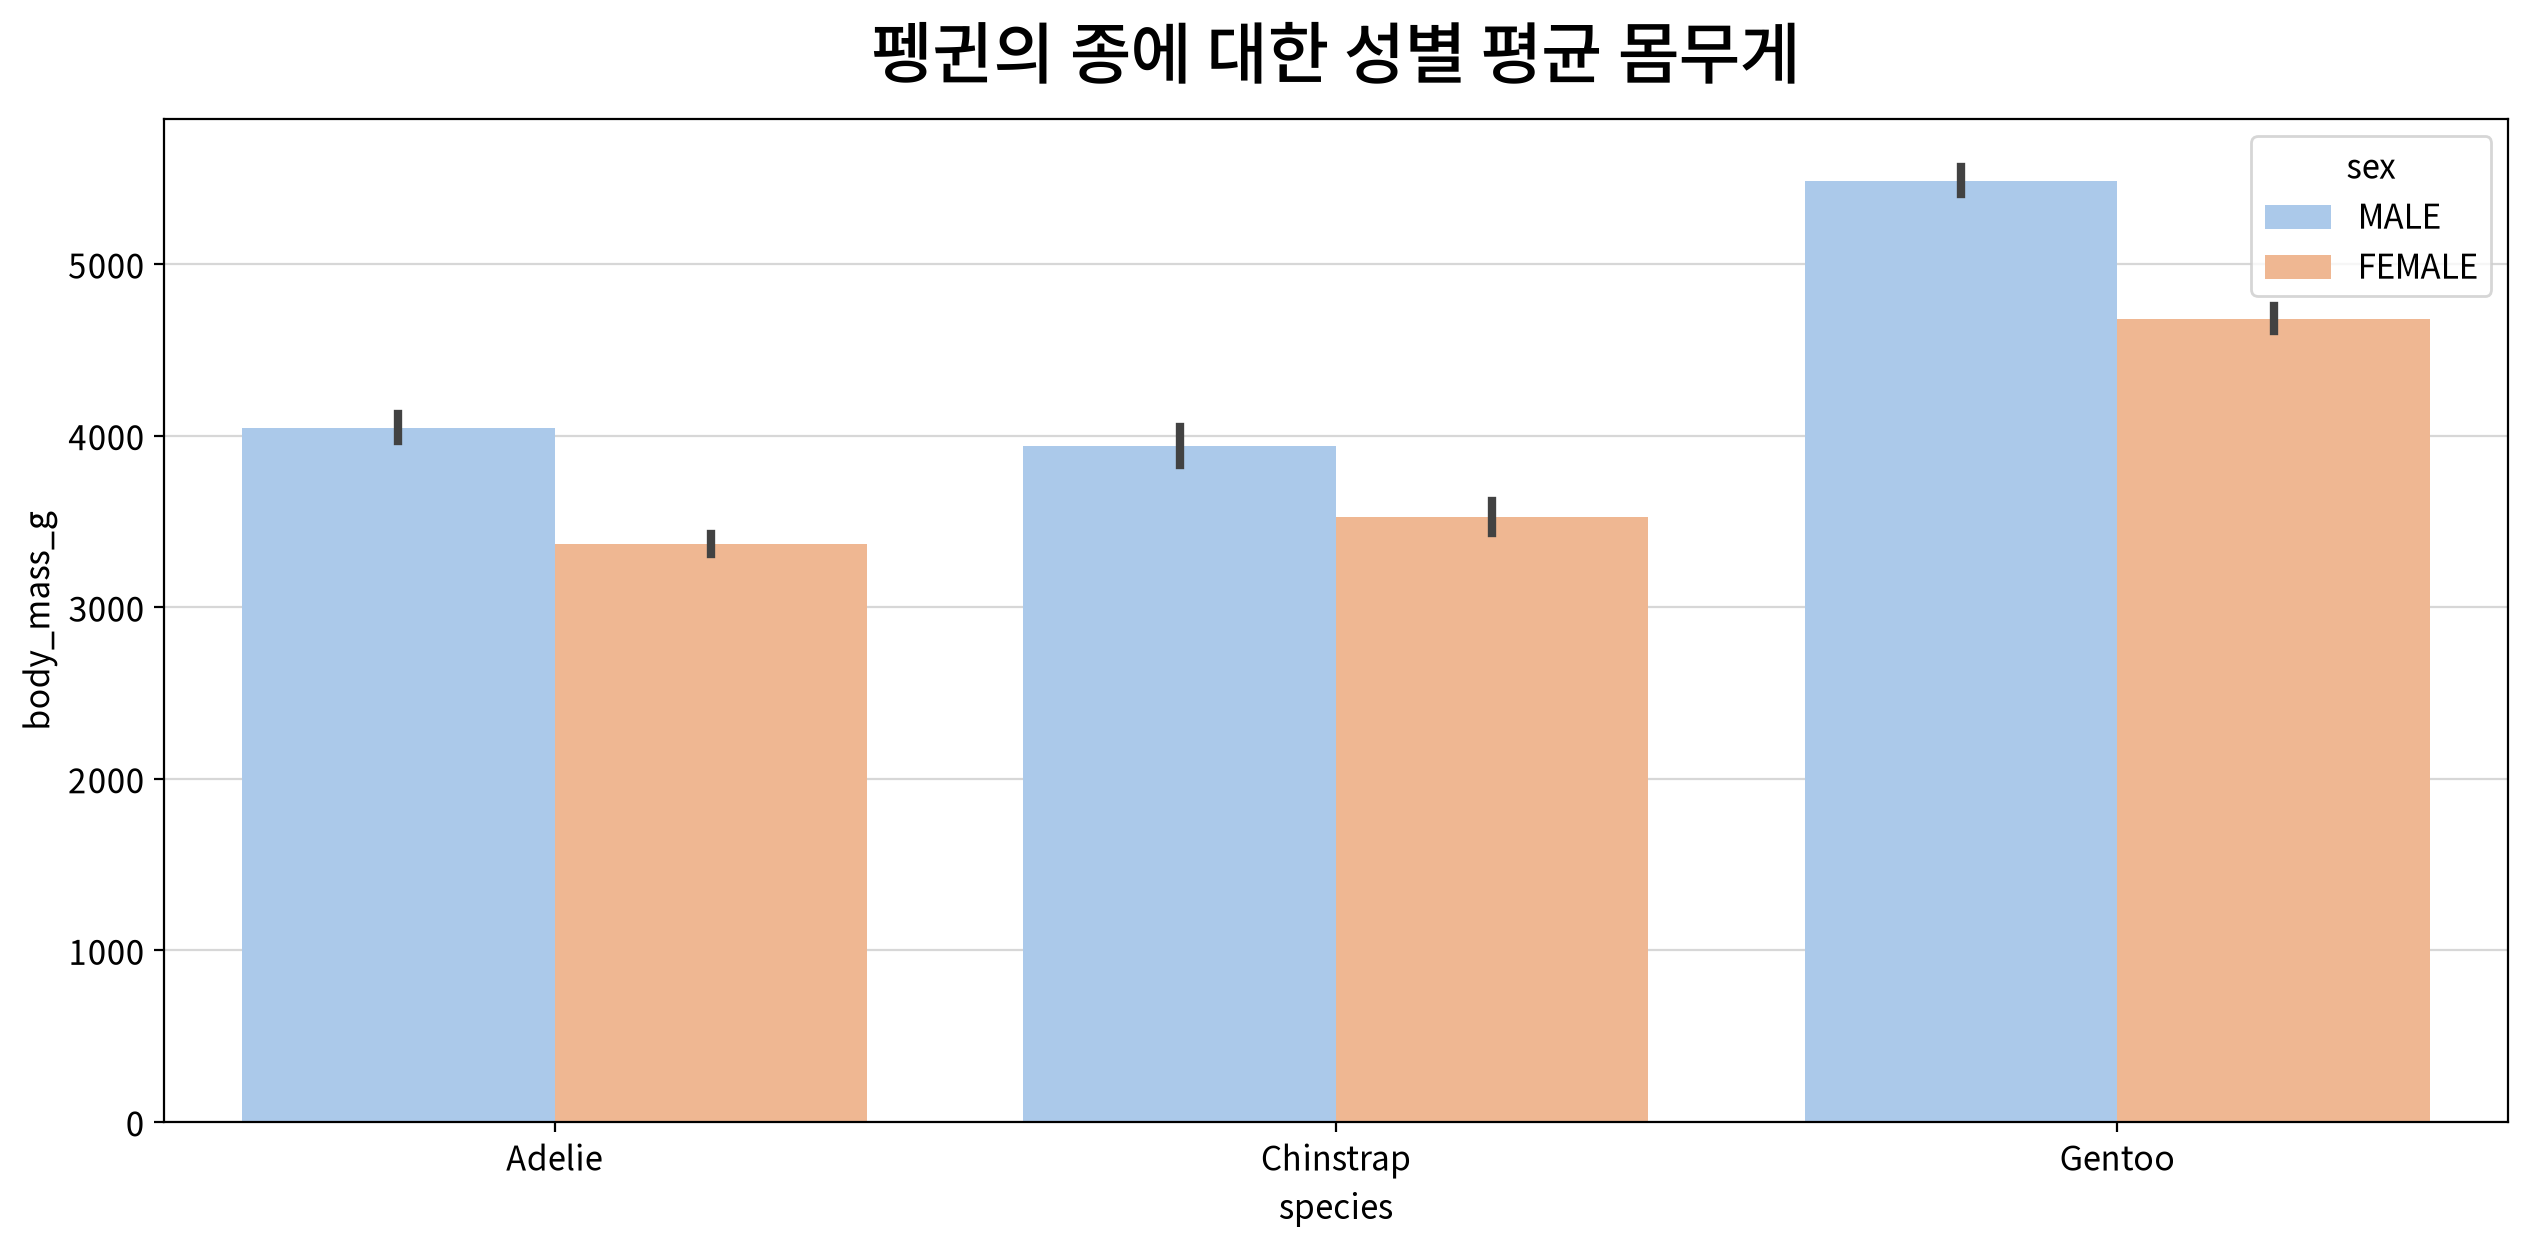

In [6]:
# 그래프 초기화
fig, ax = my_plot.init(title="펭귄의 종에 대한 성별 평균 몸무게")

# barplot 그리기
sb.barplot(
    data=origin,       # 사용할 데이터프레임
    x="species",       # x축 : 범주형 변수
    y="body_mass_g",   # y축 : 수치형 변수
    hue="sex",         # 구분할 범주형 변수
    palette="pastel"   # 색상 팔레트
)

# 그래프 표시하기
my_plot.show()

#### 💡 인사이트

- 🐧 모든 종에서 MALE 평균 몸무게가 FEMALE보다 높게 나타남.
- 📊 종 내 성별 평균 비교 시, 성별 차이는 Gentoo에서 가장 크게 보이고 Chinstrap에서 가장 작게 보임.
- 📏 Gentoo는 MALE/FEMALE 모두에서 평균 몸무게가 가장 높음.
- 🔍 Adelie와 Chinstrap는 MALE 기준으로는 비슷한 수준이고, FEMALE 기준으로도 큰 차이 없이 근접한 수준임.
- 🎯 막대 높이 기준으로 보면, 종 효과(특히 Gentoo)와 성별 효과(MALE > FEMALE)가 동시에 뚜렷하게 관찰됨.

## #03. CountPlot (빈도 그래프)

- barplot의 estimator 파라미터가 `len`으로 고정되어 있는 형태
  - x나 y파라미터 중 하나만 명목형 변수로 설정한다.
  - 설정하는 파라미터에 따라 가로/세로 형태가 결정된다.

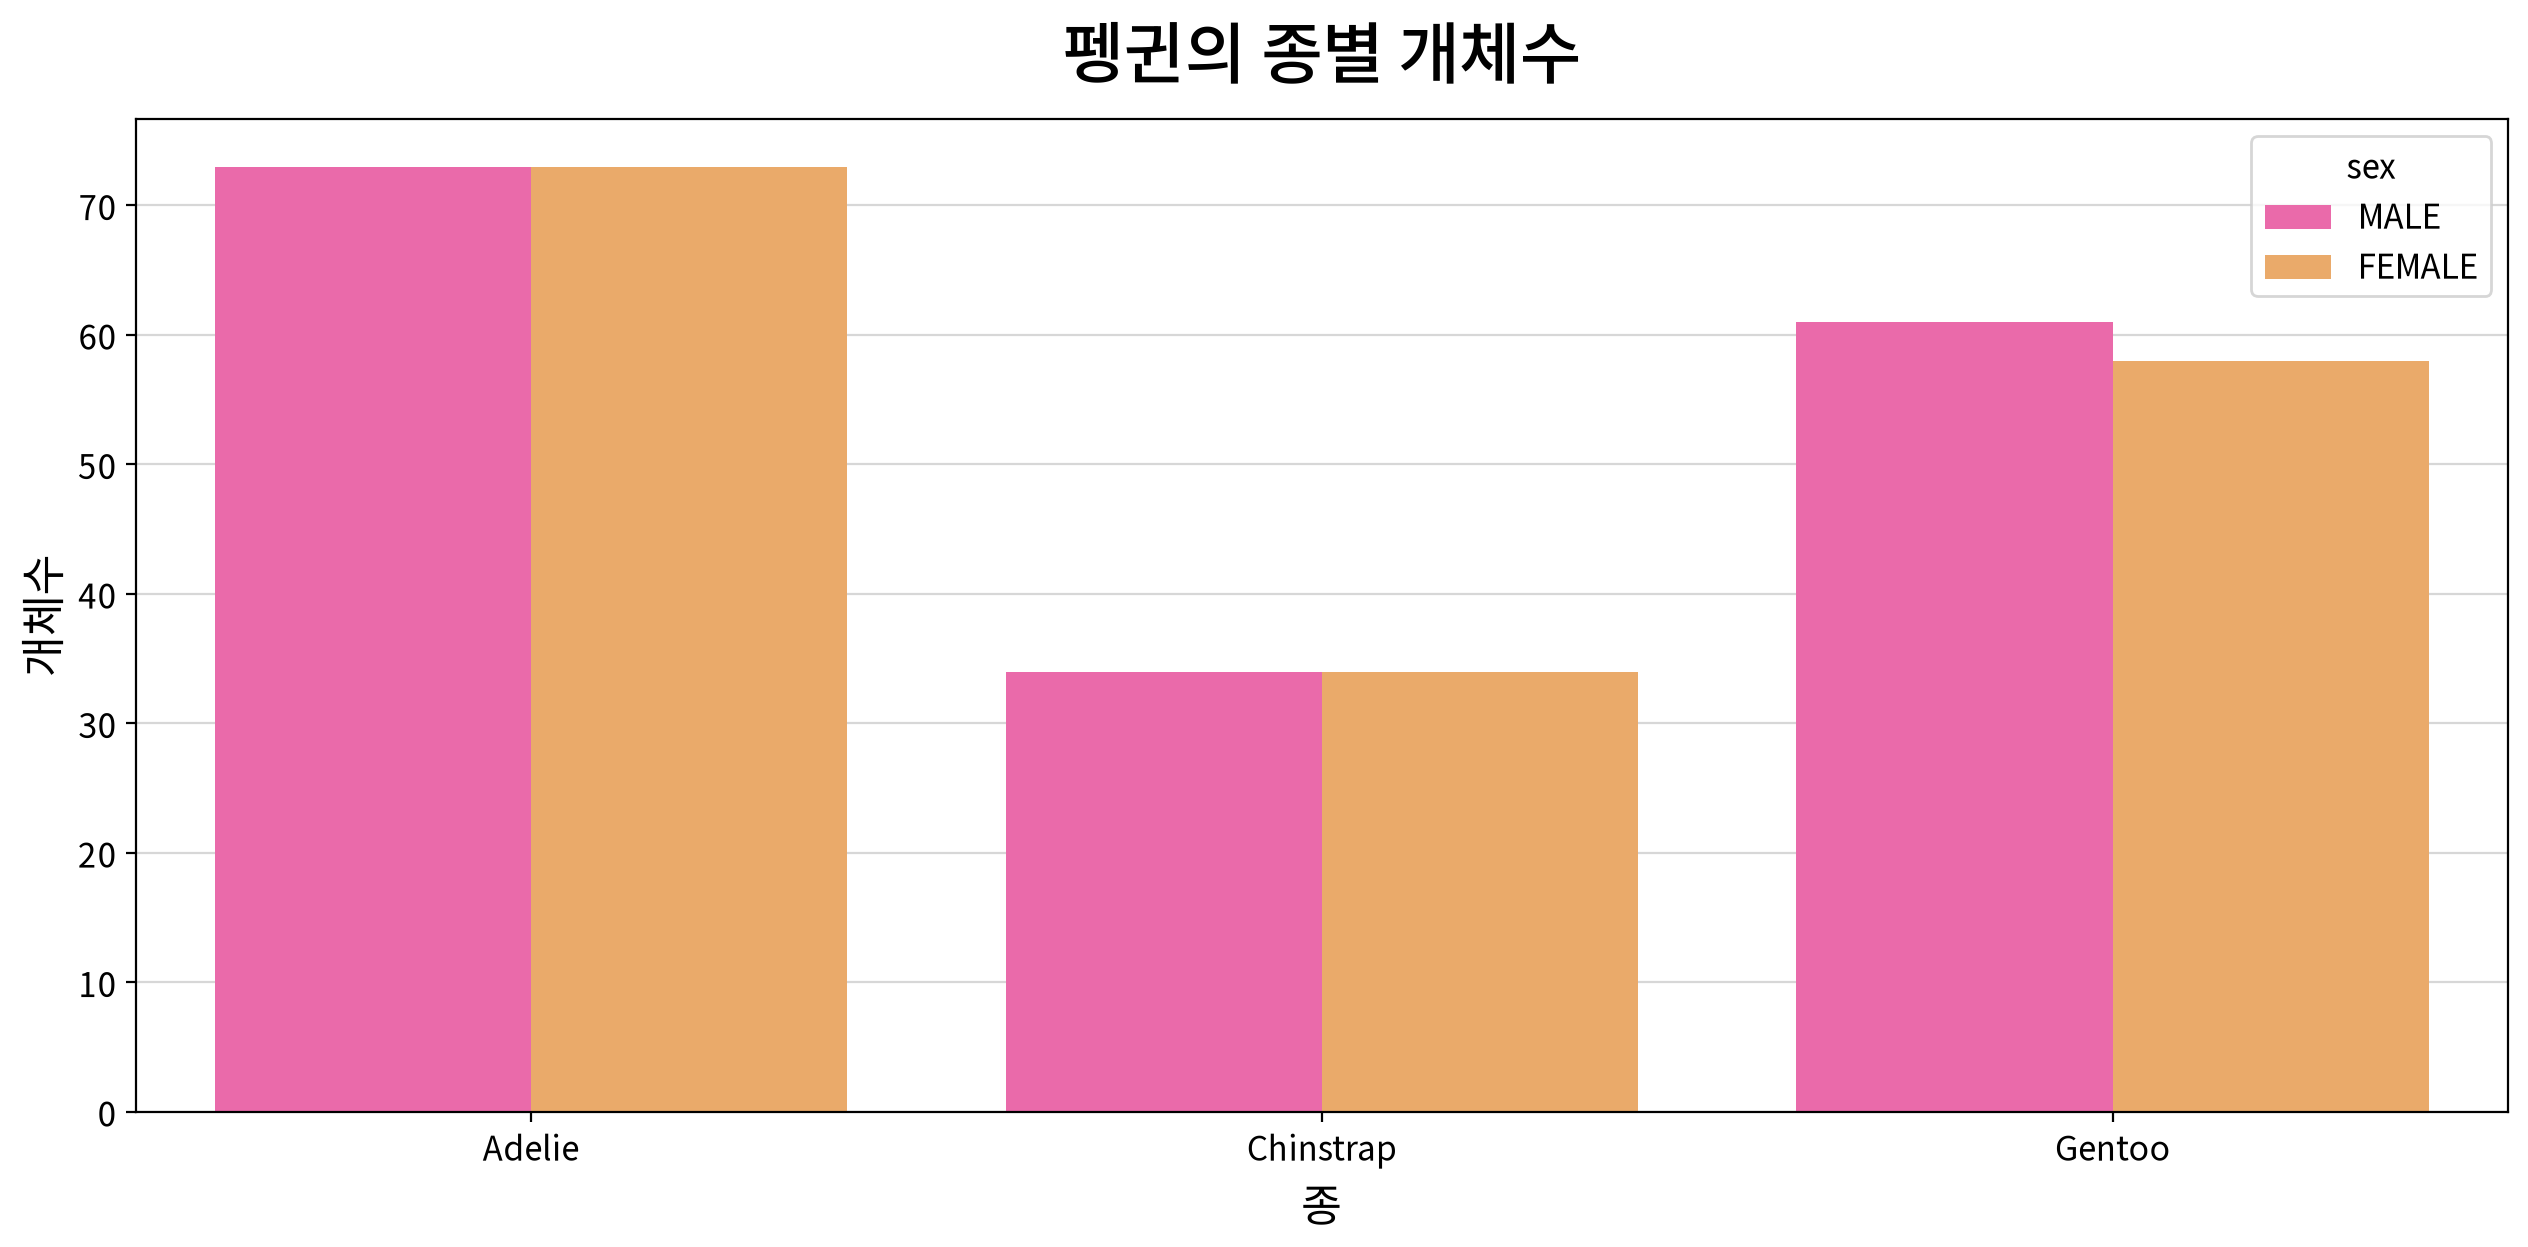

In [7]:
# 그래프 초기화
fig, ax = my_plot.init(title="펭귄의 종별 개체수", 
                       xlabel="종", ylabel="개체수")

# countplot 그리기
sb.countplot(
    data=origin,           # 사용할 데이터프레임
    x="species",           # 집계할 범주
    palette="spring",      # 색상 팔레트
    hue="sex"              # 그룹 구분
)

# 그래프 표시하기
my_plot.show()

#### 💡 인사이트

- 🐧 종별 전체 개체수는 Adelie가 가장 많고, Chinstrap이 가장 적으며, Gentoo는 그 중간 수준임.
- ⚖️ Adelie와 Chinstrap에서는 MALE/FEMALE 막대 높이가 거의 동일해 성별 개체수 균형이 뚜렷함.
- 📊 Gentoo에서는 MALE이 FEMALE보다 소폭 많아, 세 종 중 성별 차이가 가장 눈에 띄게 나타남.
- 🔎 종 내 성별 비교 기준으로 보면, 뚜렷한 성별 불균형은 전반적으로 크지 않고 대부분 비슷한 분포를 보임.
- 🎯 countplot 결과 기준으로 데이터 분포의 핵심은 종별 규모 차이(Adelie > Gentoo > Chinstrap)이며, 성별 차이는 제한적임.

## #04. 모듈화 기능 확인

### 1. BarPlot

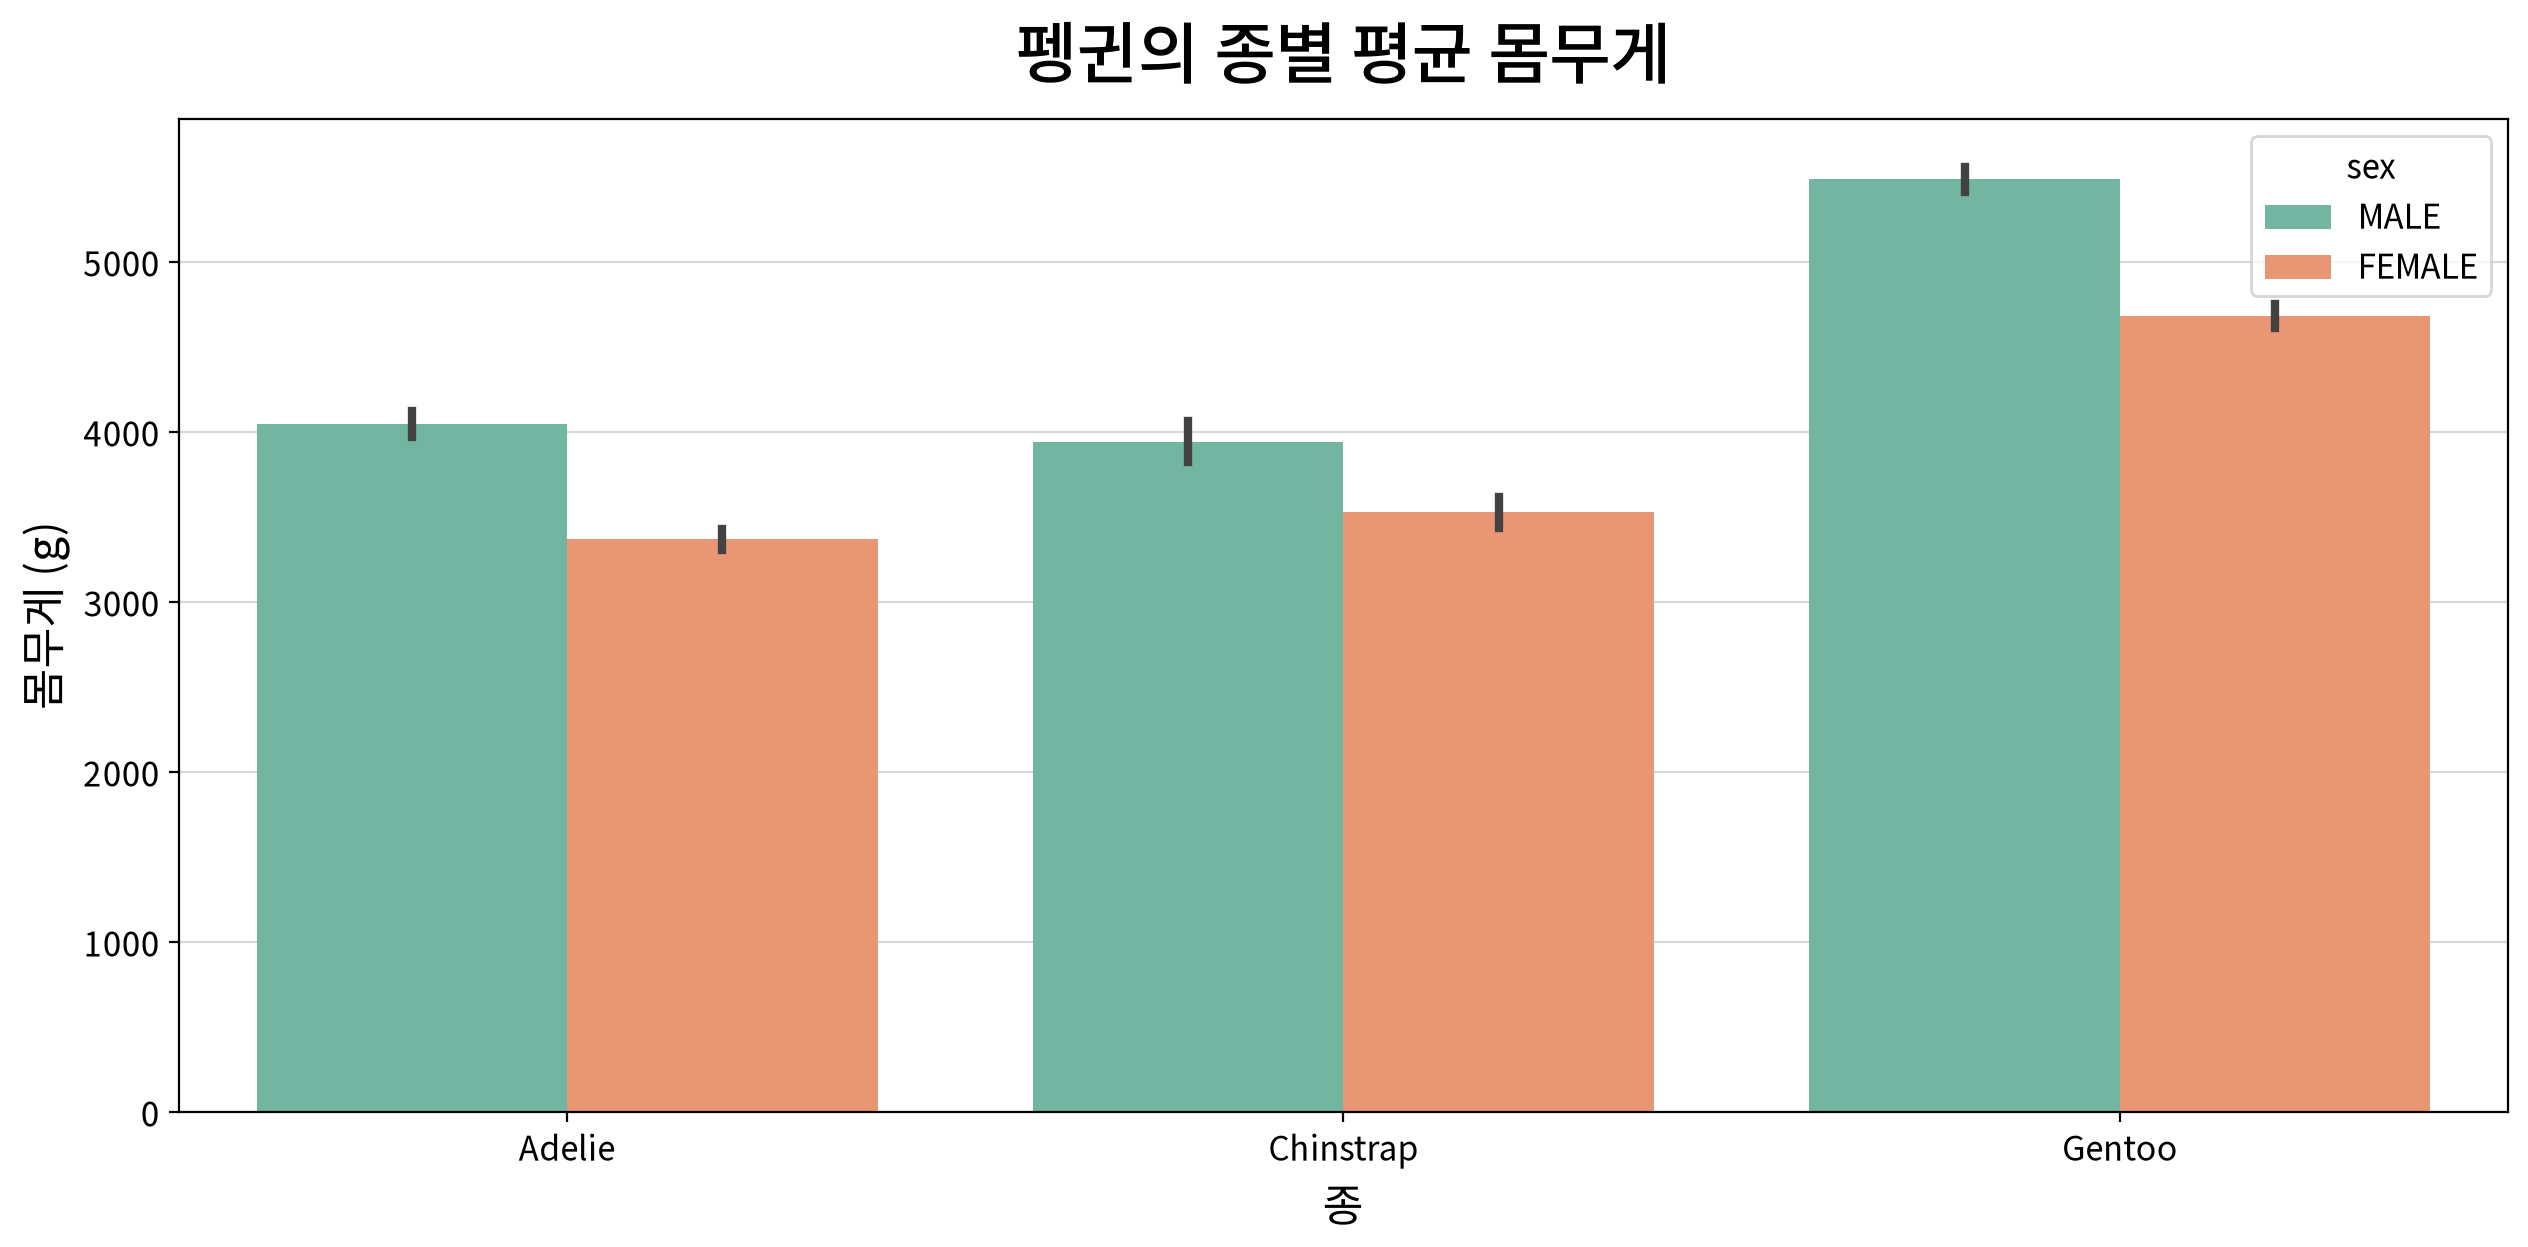

In [8]:
my_plot.barplot(data=origin, x="species", y="body_mass_g", hue="sex", 
                estimator=np.mean, palette="Set2", 
                title="펭귄의 종별 평균 몸무게", xlabel="종", ylabel="몸무게 (g)")

### 2. CountPlot

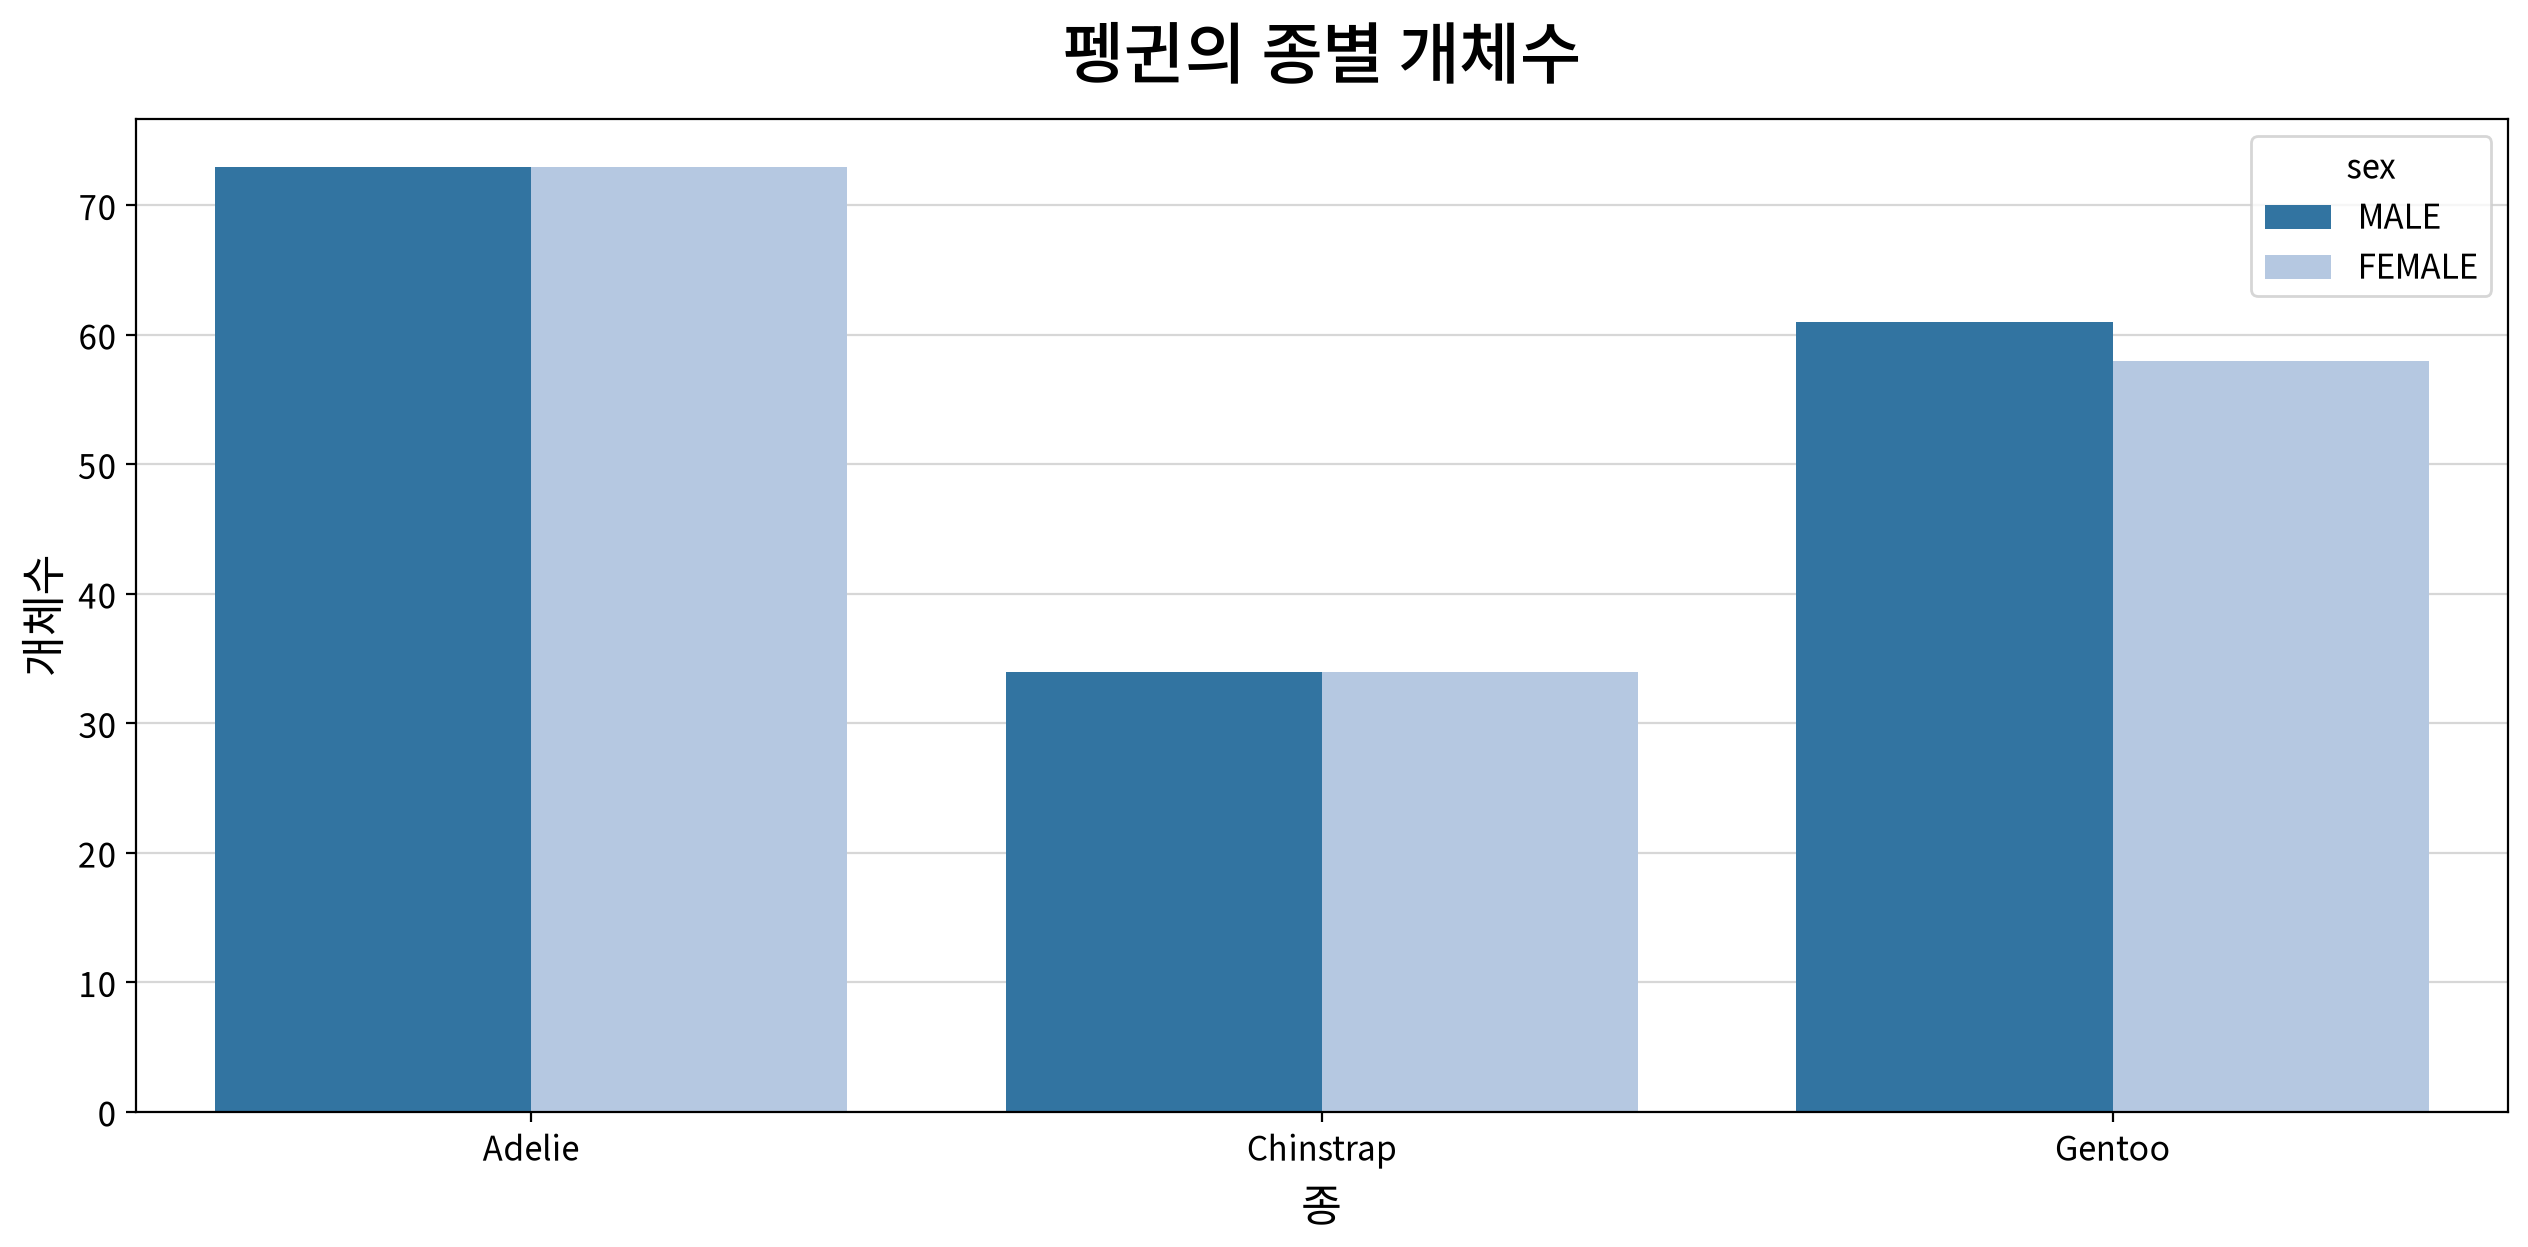

In [9]:
my_plot.countplot(data=origin, x="species", hue="sex", palette="tab20",
                   title="펭귄의 종별 개체수", xlabel="종", ylabel="개체수")